# Image Transformation Pipeline with PyTorch
# Part 3: Complete Pipeline

This notebook builds full training/validation transformation pipelines.

Topics covered:
- Building training and validation pipelines
- Best practices for data augmentation
- Working with real datasets (CIFAR-10)
- Creating custom transformations
- Integration with DataLoader
- Visualization and debugging
- Performance optimization


In [21]:
# =========================================================================
# SETUP AND IMPORTS
# =========================================================================

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time
from typing import Tuple, List

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


PyTorch version: 2.9.1+cu128
Torchvision version: 0.24.1+cu128
CUDA available: False


## 1. Building Training and Validation Pipelines

Key principles:
- Training: geometric augmentation → color augmentation → advanced augmentation → normalization.
- Validation: deterministic resize/crop → normalization (same stats as training) for consistent evaluation.


### 1.1 Standard ImageNet-Style Pipeline

This is the standard pipeline used for ImageNet and transfer learning.


In [22]:
# ImageNet statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transforms
train_transforms_imagenet = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0), ratio=(0.75, 1.33)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

# Validation transforms
val_transforms_imagenet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Training Pipeline (ImageNet-style):")
print("  1. RandomResizedCrop(224) - scale=(0.08, 1.0)")
print("  2. RandomHorizontalFlip(p=0.5)")
print("  3. ColorJitter - moderate strength")
print("  4. ToTensor")
print("  5. Normalize with ImageNet stats")
print("  6. RandomErasing(p=0.25)")

print("Validation Pipeline (ImageNet-style):")
print("  1. Resize(256)")
print("  2. CenterCrop(224)")
print("  3. ToTensor")
print("  4. Normalize with ImageNet stats")


Training Pipeline (ImageNet-style):
  1. RandomResizedCrop(224) - scale=(0.08, 1.0)
  2. RandomHorizontalFlip(p=0.5)
  3. ColorJitter - moderate strength
  4. ToTensor
  5. Normalize with ImageNet stats
  6. RandomErasing(p=0.25)
Validation Pipeline (ImageNet-style):
  1. Resize(256)
  2. CenterCrop(224)
  3. ToTensor
  4. Normalize with ImageNet stats


### 1.2 CIFAR-10 Style Pipeline (32×32 Images)

Smaller images need different augmentation: padding + random crop, smaller rotations, and conservative color changes.


In [23]:
# CIFAR-10 statistics
CIFAR10_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR10_STD = [0.2470, 0.2435, 0.2616]

# Training transforms for CIFAR-10
train_transforms_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2)),
])

# Validation transforms for CIFAR-10
val_transforms_cifar = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

print("Training Pipeline (CIFAR-10):")
print("  1. RandomCrop(32, padding=4)")
print("  2. RandomHorizontalFlip(p=0.5)")
print("  3. ColorJitter - conservative")
print("  4. ToTensor")
print("  5. Normalize with CIFAR-10 stats")
print("  6. RandomErasing(p=0.2)")

print("Validation Pipeline (CIFAR-10):")
print("  1. ToTensor")
print("  2. Normalize with CIFAR-10 stats")


Training Pipeline (CIFAR-10):
  1. RandomCrop(32, padding=4)
  2. RandomHorizontalFlip(p=0.5)
  3. ColorJitter - conservative
  4. ToTensor
  5. Normalize with CIFAR-10 stats
  6. RandomErasing(p=0.2)
Validation Pipeline (CIFAR-10):
  1. ToTensor
  2. Normalize with CIFAR-10 stats


### 1.3 Loading CIFAR-10 Dataset


In [24]:

from pathlib import Path

# Resolve data directory in both notebooks (no __file__) and scripts
base_dir = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if base_dir.name != "Week07" and (base_dir / "Week07").exists():
    base_dir = base_dir / "Week07"
    
data_root = base_dir / "data"
data_root.mkdir(parents=True, exist_ok=True)

print("Downloading CIFAR-10 dataset...")

train_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=True,
    transform=train_transforms_cifar,
)

val_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=True,
    download=False,
    transform=val_transforms_cifar,
)

# Hold out the official test split for final evaluation
# (CIFAR-10 provides a separate test set of 10k images)
test_dataset = torchvision.datasets.CIFAR10(
    root=data_root,
    train=False,
    download=True,
    transform=val_transforms_cifar,
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")


Training set size: 50000
Validation set size: 50000
Test set size: 10000
Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 1.4 Visualizing Augmented Samples


Showing multiple augmentations of the SAME image:


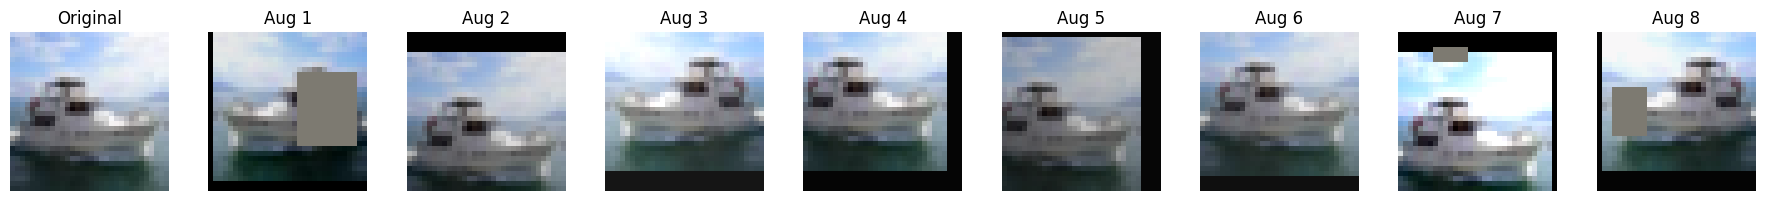

Showing different images from VALIDATION set (no augmentation):


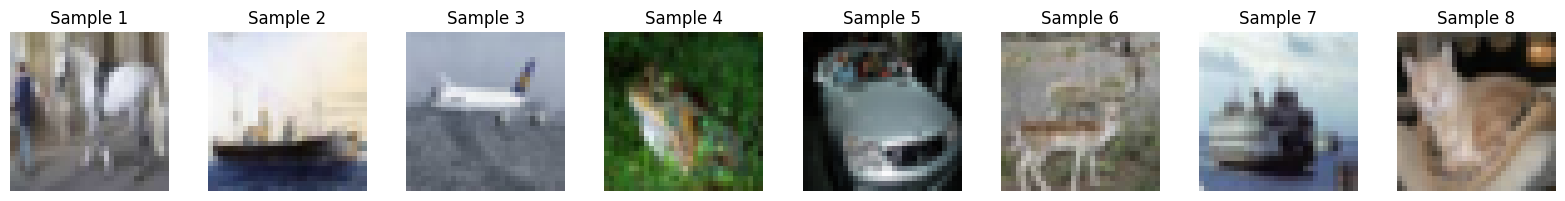

In [25]:

# Helper: denormalize for display
def denormalize(tensor, mean, std):
    """Denormalize a tensor for visualization."""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Helper: show augmented samples
def show_augmented_samples(dataset, num_samples=8, same_image=True):
    """Show multiple augmented versions of the same image or different images."""
    transform = getattr(dataset, "transform", None)
    if transform is None:
        raise ValueError("Dataset has no transform set for augmentation display.")

    if same_image:
        original_dataset = torchvision.datasets.CIFAR10(
            root='./data', train=True, download=False, transform=None
        )
        idx = np.random.randint(0, len(original_dataset))
        original_img, label = original_dataset[idx]

        images = []
        for _ in range(num_samples):
            img_tensor = transform(original_img)
            img_denorm = denormalize(img_tensor, CIFAR10_MEAN, CIFAR10_STD)
            images.append(img_denorm)

        original_tensor = transforms.ToTensor()(original_img)
        images = [original_tensor] + images
    else:
        indices = np.random.choice(len(dataset), num_samples, replace=False)
        images = []
        for idx in indices:
            img, _ = dataset[idx]
            img_denorm = denormalize(img, CIFAR10_MEAN, CIFAR10_STD)
            images.append(img_denorm)

    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    if n == 1:
        axes = [axes]

    for idx, (img, ax) in enumerate(zip(images, axes)):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title("Original" if idx == 0 and same_image else (f"Aug {idx}" if same_image else f"Sample {idx+1}"))
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print("Showing multiple augmentations of the SAME image:")
show_augmented_samples(train_dataset, num_samples=8, same_image=True)

print("Showing different images from VALIDATION set (no augmentation):")
show_augmented_samples(val_dataset, num_samples=8, same_image=False)


## 2. Custom Transformations

Creating custom transformations allows you to implement domain-specific augmentation, combine operations, or add conditional logic.


### 2.1 Simple Custom Transformation


In [26]:
class AddGaussianNoise:
    """Add Gaussian noise to an image tensor."""

    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        noisy_tensor = tensor + noise
        return torch.clamp(noisy_tensor, 0, 1)

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

custom_transform = transforms.Compose([
    transforms.ToTensor(),
    AddGaussianNoise(mean=0.0, std=0.05),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

print("Custom transformation: AddGaussianNoise")
print(custom_transform)


Custom transformation: AddGaussianNoise
Compose(
    ToTensor()
    AddGaussianNoise(mean=0.0, std=0.05)
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
)


### 2.2 Advanced Custom Transformation (Cutout)


Custom transformation: Cutout
Compose(
    ToTensor()
    Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.247, 0.2435, 0.2616])
    Cutout(n_holes=1, length=16)
)
Visualizing Cutout transformation:


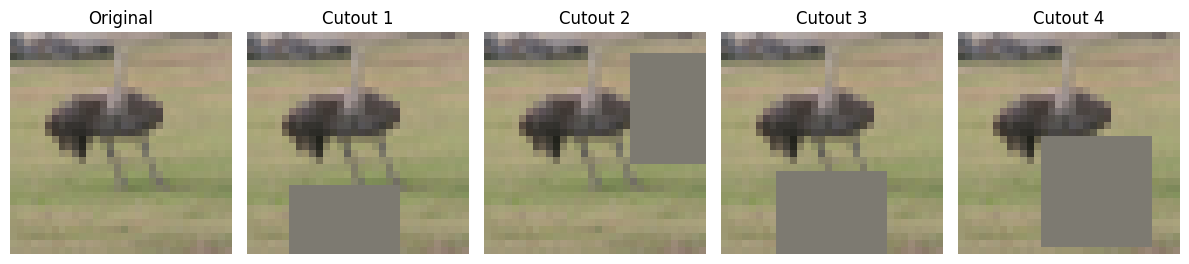

In [27]:
class Cutout:
    """Randomly mask out square regions of the image."""

    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = torch.ones((h, w), dtype=torch.float32)

        for _ in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)
            y1 = np.clip(y - self.length // 2, 0, h)
            y2 = np.clip(y + self.length // 2, 0, h)
            x1 = np.clip(x - self.length // 2, 0, w)
            x2 = np.clip(x + self.length // 2, 0, w)
            mask[y1:y2, x1:x2] = 0.0

        mask = mask.expand_as(img)
        return img * mask

    def __repr__(self):
        return f"{self.__class__.__name__}(n_holes={self.n_holes}, length={self.length})"

cutout_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    Cutout(n_holes=1, length=16),
])

print("Custom transformation: Cutout")
print(cutout_transform)

print("Visualizing Cutout transformation:")
cutout_demo_dataset = torchvision.datasets.CIFAR10(
    root=data_root, train=True, download=False, transform=None
)
img, label = cutout_demo_dataset[42]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(1, 5):
    img_tensor = cutout_transform(img)
    img_denorm = denormalize(img_tensor, CIFAR10_MEAN, CIFAR10_STD)
    axes[i].imshow(img_denorm.permute(1, 2, 0))
    axes[i].set_title(f"Cutout {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### 2.3 Conditional Custom Transformation


In [28]:
class RandomTransformChoice:
    """Randomly choose one transformation from a list."""

    def __init__(self, transforms_list):
        self.transforms = transforms_list

    def __call__(self, img):
        transform = np.random.choice(self.transforms)
        return transform(img)

    def __repr__(self):
        format_string = self.__class__.__name__ + '('
        for t in self.transforms:
            format_string += f"{t}"
        format_string += ')'
        return format_string

random_choice_transform = RandomTransformChoice([
    transforms.ColorJitter(brightness=0.5),
    transforms.RandomRotation(15),
    transforms.GaussianBlur(kernel_size=5),
])

print("Random choice transformation:")
print(random_choice_transform)


Random choice transformation:
RandomTransformChoice(ColorJitter(brightness=(0.5, 1.5), contrast=None, saturation=None, hue=None)RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)GaussianBlur(kernel_size=(5, 5), sigma=(0.1, 2.0)))


## 3. Integration with DataLoader


### 3.1 Creating DataLoaders


In [29]:

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")


Training batches: 391
Validation batches: 391
Test batches: 79
Batch size: 128


### 3.2 Visualizing Batches


Training batch (with augmentation):


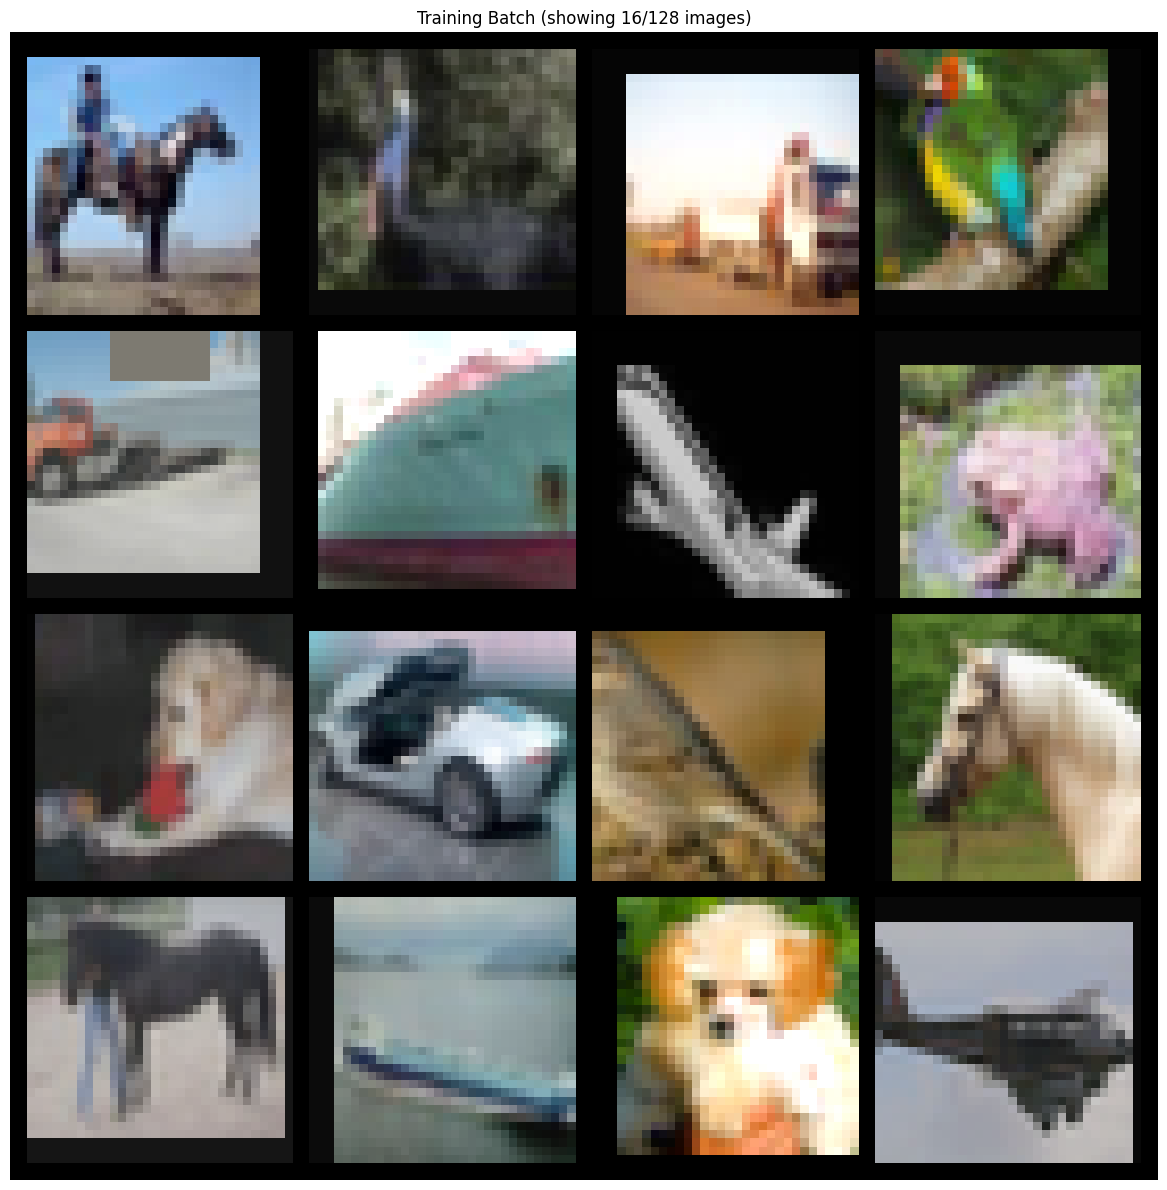

Labels for first 16 images:
['horse', 'bird', 'truck', 'bird', 'truck', 'ship', 'airplane', 'frog', 'dog', 'automobile', 'bird', 'horse', 'horse', 'ship', 'dog', 'airplane']
Validation batch (no augmentation):


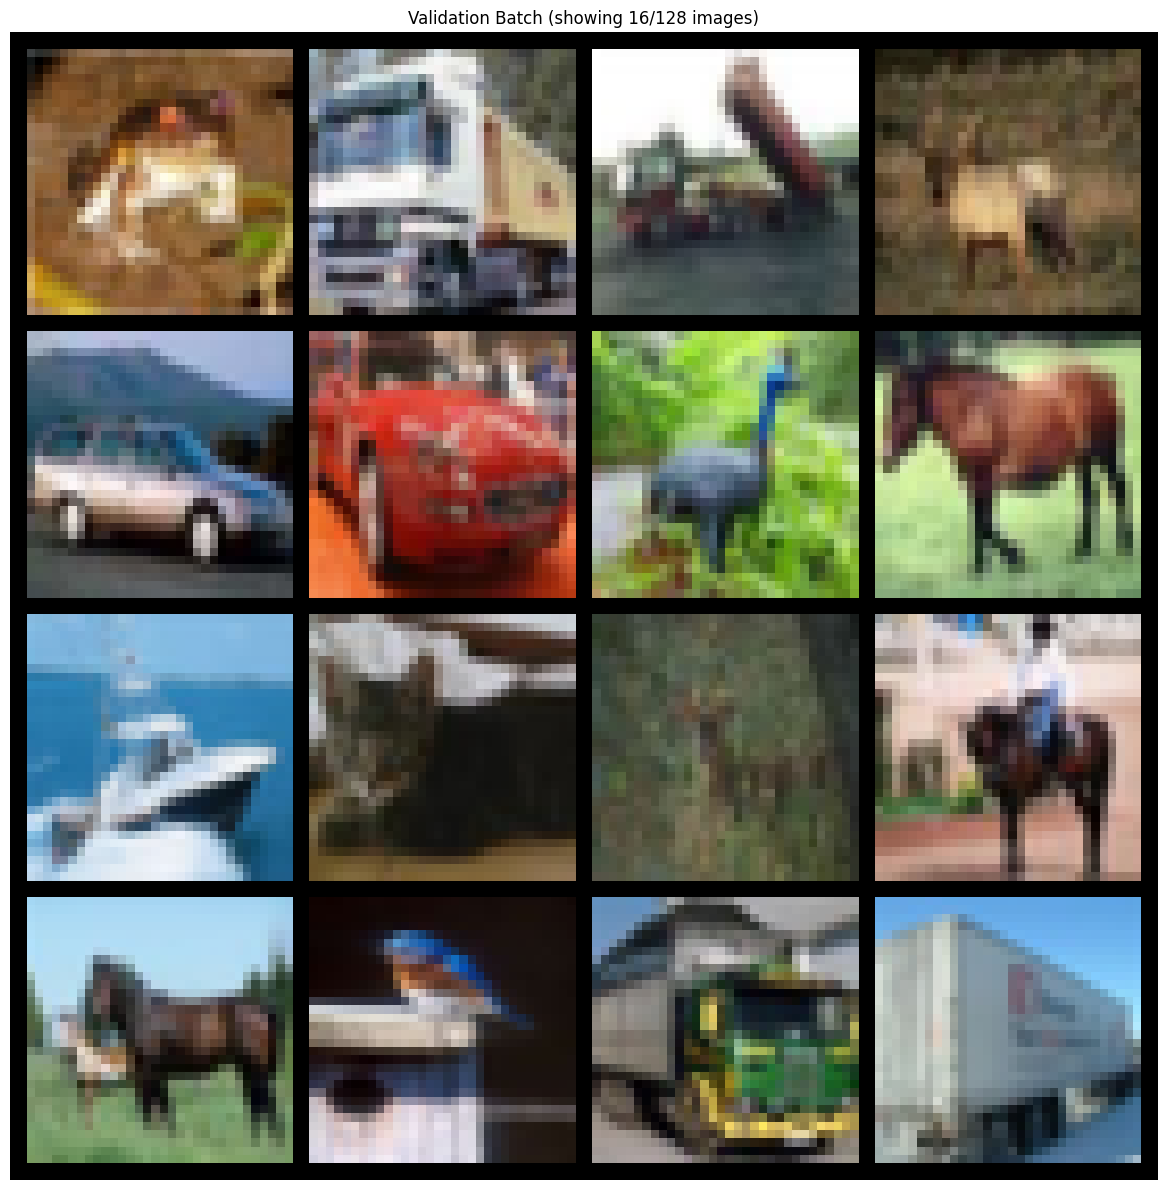

Labels for first 16 images:
['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat', 'deer', 'horse', 'horse', 'bird', 'truck', 'truck']


In [30]:
def show_batch(loader, dataset_name="Dataset", num_images=16):
    images, labels = next(iter(loader))

    images_denorm = torch.stack([
        denormalize(img, CIFAR10_MEAN, CIFAR10_STD) for img in images[:num_images]
    ])

    grid = torchvision.utils.make_grid(images_denorm, nrow=4, padding=2)

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"{dataset_name} Batch (showing {num_images}/{len(images)} images)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    class_names = train_dataset.classes
    print(f"Labels for first {num_images} images:")
    print([class_names[label] for label in labels[:num_images].tolist()])

print("Training batch (with augmentation):")
show_batch(train_loader, "Training", num_images=16)

print("Validation batch (no augmentation):")
show_batch(val_loader, "Validation", num_images=16)


### 3.3 Performance Considerations

Tips for optimizing data loading:
1. Use `num_workers` > 0 for parallel loading.
2. Use `pin_memory=True` when training on GPU.
3. Keep transforms lightweight.
4. Consider caching preprocessed data for validation.
5. Use `persistent_workers=True` for long training jobs.


In [31]:
def benchmark_dataloader(loader, num_batches=50):
    """Measure data loading speed."""
    start_time = time.time()
    for i, (images, labels) in enumerate(loader):
        if i >= num_batches:
            break
    elapsed = time.time() - start_time
    images_per_sec = (num_batches * loader.batch_size) / elapsed
    return elapsed, images_per_sec

print("Benchmarking data loading speed...")
train_time, train_speed = benchmark_dataloader(train_loader, num_batches=50)
print(f"Training loader: {train_time:.2f}s for 50 batches")
print(f"Speed: {train_speed:.0f} images/second")

val_time, val_speed = benchmark_dataloader(val_loader, num_batches=50)
print(f"Validation loader: {val_time:.2f}s for 50 batches")
print(f"Speed: {val_speed:.0f} images/second")


Benchmarking data loading speed...
Training loader: 2.35s for 50 batches
Speed: 2720 images/second
Validation loader: 0.85s for 50 batches
Speed: 7561 images/second


## 4. Best Practices and Guidelines

DATA AUGMENTATION BEST PRACTICES:

1. **Start conservative, increase gradually**: begin minimal, increase if overfitting (train >> val accuracy).
2. **Match augmentation to your problem**: e.g., object classification (RandomResizedCrop, flip), fine-grained (less aggressive), medical (careful with color), satellite (allow vertical flips/rotations).
3. **Normalization is critical**: always normalize; use ImageNet stats for transfer learning or dataset-specific stats; same normalization for train/val.
4. **Common augmentation strengths**:
   - Small datasets (<10K): stronger (ColorJitter(0.4,0.4,0.4,0.1), RandomErasing p≈0.3, maybe mixup/cutmix).
   - Medium (10K–100K): moderate (ColorJitter ≈0.3, RandomErasing p≈0.2).
   - Large (>100K): conservative (ColorJitter ≈0.2, RandomErasing p≈0.1).
5. **Validation rules**: never augment val/test, use deterministic transforms, same normalization, consistent preprocessing.
6. **Debugging augmentation**: visualize often, check aggressiveness, ensure labels still make sense, monitor training dynamics.
7. **Performance optimization**: multiple workers, `pin_memory`, cache validation, profile bottlenecks.
8. **Advanced techniques**: AutoAugment/RandAugment, MixUp/CutMix, learned augmentation policies, tune augmentation strength.


## Practical Example: Complete Training Pipeline


Model initialized on device: cpu
Number of parameters: 2,122,186
Training for 10 epochs...
Epoch 1/10 - Train Loss: 1.8149, Train Acc: 33.43% | Val Loss: 1.4354, Val Acc: 48.44%
Epoch 2/10 - Train Loss: 1.5004, Train Acc: 45.47% | Val Loss: 1.2224, Val Acc: 55.58%
Epoch 3/10 - Train Loss: 1.3318, Train Acc: 52.08% | Val Loss: 1.1003, Val Acc: 60.64%
Epoch 4/10 - Train Loss: 1.2210, Train Acc: 56.30% | Val Loss: 0.9444, Val Acc: 66.76%
Epoch 5/10 - Train Loss: 1.1404, Train Acc: 59.72% | Val Loss: 0.8931, Val Acc: 68.97%
Epoch 6/10 - Train Loss: 1.0836, Train Acc: 61.63% | Val Loss: 0.8449, Val Acc: 70.81%
Epoch 7/10 - Train Loss: 1.0430, Train Acc: 63.10% | Val Loss: 0.8101, Val Acc: 71.99%
Epoch 8/10 - Train Loss: 1.0073, Train Acc: 64.49% | Val Loss: 0.7769, Val Acc: 73.03%
Epoch 9/10 - Train Loss: 0.9787, Train Acc: 65.73% | Val Loss: 0.7309, Val Acc: 74.70%
Epoch 10/10 - Train Loss: 0.9419, Train Acc: 66.76% | Val Loss: 0.7037, Val Acc: 75.79%


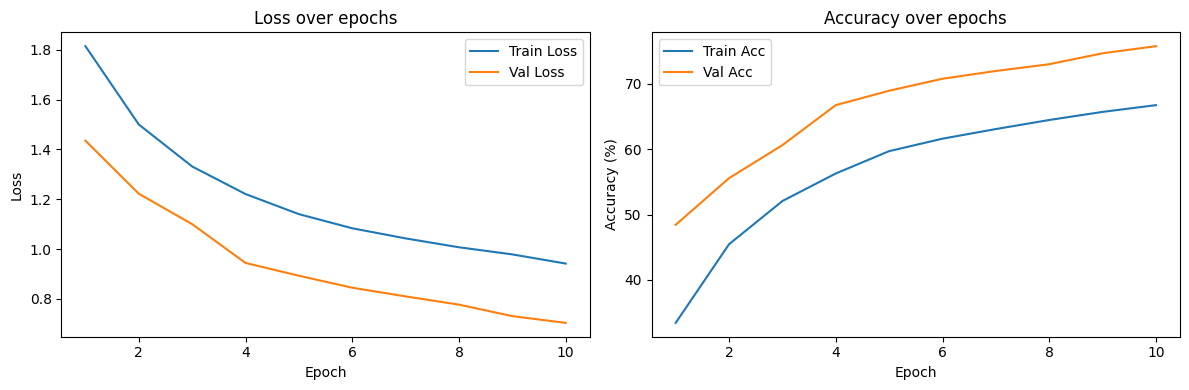

Computing confusion matrix on test set...


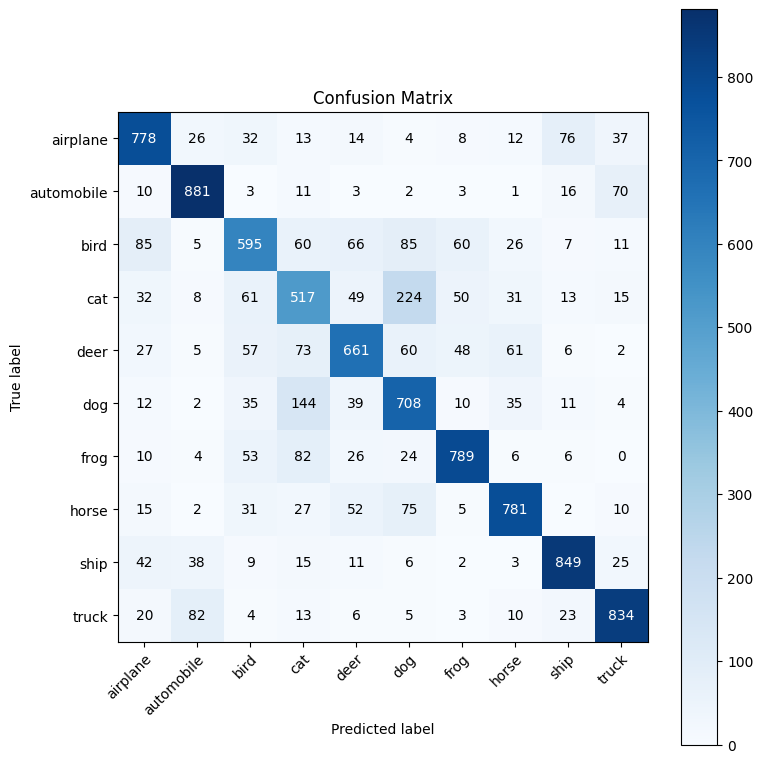

In [32]:

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Initialize model
num_classes = 10
model = SimpleCNN(num_classes=num_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

print(f"Model initialized on device: {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)


def run_epoch(model, loader, criterion, optimizer=None, device='cpu', max_batches=None):
    """Run one epoch. If optimizer is None, runs in eval mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if max_batches is not None and batch_idx + 1 >= max_batches:
            break

    epoch_loss = running_loss / (batch_idx + 1)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_and_validate(model, train_loader, val_loader, criterion, optimizer, device, epochs=5, max_batches_per_epoch=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, device, max_batches=max_batches_per_epoch)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None, device=device, max_batches=max_batches_per_epoch)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch}/{epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    return history


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], label='Train Loss')
    axes[0].plot(epochs, history["val_loss"], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss over epochs')
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label='Train Acc')
    axes[1].plot(epochs, history["val_acc"], label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy over epochs')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def compute_confusion_matrix(model, loader, device, num_classes):
    conf_mat = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            for t, p in zip(labels.view(-1), preds.view(-1)):
                conf_mat[t.long(), p.long()] += 1
    return conf_mat.cpu().numpy()


def plot_confusion_matrix(conf_mat, class_names):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(conf_mat, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=range(len(class_names)), yticks=range(len(class_names)),
           xticklabels=class_names, yticklabels=class_names,
           xlabel='Predicted label', ylabel='True label', title='Confusion Matrix')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = conf_mat.max() / 2.
    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            ax.text(j, i, format(conf_mat[i, j], 'd'), ha="center", va="center",
                    color="white" if conf_mat[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

# === Run training/validation ===
num_epochs = 10
max_batches_per_epoch = None  # set to a small int (e.g., 50) for faster demo runs

print(f"Training for {num_epochs} epochs...")
history = train_and_validate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=num_epochs,
    max_batches_per_epoch=max_batches_per_epoch,
)

plot_history(history)

# === Evaluate and visualize confusion matrix ===
print("Computing confusion matrix on test set...")
conf_mat = compute_confusion_matrix(model, test_loader, device, num_classes=num_classes)
plot_confusion_matrix(conf_mat, class_names=train_dataset.classes)


## Key Takeaways - Part 3

1. **Pipeline design**: training = augmentation + normalization; validation = deterministic preprocessing + same normalization; adapt to image size.
2. **Custom transforms**: implement `__call__`/`__repr__` for domain-specific augmentation.
3. **DataLoader integration**: transforms applied at load time; use workers/pin_memory; always visualize batches.
4. **Best practices**: start conservative, match domain, normalize consistently, never augment validation.
5. **Debugging/performance**: visualize often, monitor aggressiveness, benchmark data loading, consider advanced policies (AutoAugment, MixUp/CutMix).
